# Vinton Dome Airborne Gravity Gradiometry QC

Mark Dransfield, October 2024

## Introductory Notes to the Reader

> This notebook provides examples of the use of many AirGravQC functions one might use in QC. These functions cover data from airborne gravimetry surveys and gradiometry ("Falcon" and "AirFTG" types) surveys. In practice one would not have all of these different types of data in one QC notebook and it is only done here so that you can see a variety of AirGravQC in one place.

> Throughout this notebook, text indented like this paragraph indicates tutorial commentary intended to explain the purpose, or highlight some feature of, the code and text of the nearby cells. The commentary is an addition to the notebook and is intended to provide extra information to someone planning to use `AirGravQC`.

> The commentary does not document the software but the usual `CMD-I` click on any function will provide the doc-string help. More information can be found in the `AirGravQC` documentation.

> Here, we are using data from the Air-FTG Vinton Dome survey. These data were kindly supplied by Bell Geospace.

> The notebook shows examples of the use of AirGravQC function in QC review of FTG data.

> The introduction usually contains a summary of the data and results of QC. It should look like a management summary and should be written according to the needs of the project.

> This particular notebook is actually using data flown as a test survey and so the words in the Introduction are entirely fictional. They are just there to demonstrate what an introduction might look like.

## Introduction

This notebook summarises the QC of the field data delivered by Bell Geospace on 1 Apr 2021 for the Important Customer's (IC) Airborne Gravity Gradiometry (Air-FTG) Survey flown in over Vinton Dome.

The Vinton Dome Block is Bell Geospace Project project number 001 and IC project number IC5000.

The notebook is organised in line with the Technical Specifications for the survey.

A total of 2,360.5 km of data (out of a planned 4,421.3 km) were delivered from 4 flights and 37 lines.

~**All data passed review and were accepted with no re-flights.**~

Five lines were marked for re-flights. The re-flights have a minimum length of 11.2 km each, totalling 56 km. Accordingly 2304.5 km are accepted.

The first section of this notebook imports the data into the QC system and summarises the contents. The QC checks of the data are organised into following sections: Reports and Data Formats, Navigation and Positioning, Gravity, and Grids.

> The idea is that every QC check required by the contract and performed by the QC person will be in this notebook. Many checks are performed by running code from `AirGravQC` and the call to the code, and the output, are contained herein. Some other checks (for example, that a Daily Report was delivered each day) are not amenable to a check by software but they should still be reported, with the outcome of the check, within the notebook. There are also a few additional checks I like to perform. Some fall naturally under the umbrella of "best practice" and some are based on my experience. The reader should not feel obliged to use these checks themselves but they might find them useful.

> Colour coding the results makes it easy to find the areas that require more work.

### QC Colour Coding

Summary cells are coloured to quickly indicated status against QC. The colours are:

<div class="alert alert-block alert-success">
Delivery passed QC.
<div>

<div class="alert alert-block alert-info">
Delivery was not checked, or the check is not applicable, or there is a minor shortcoming but the data are acceptable.
<div>

<div class="alert alert-block alert-warning">
Delivery failed QC and problem has been reported for rectification.
<div>

<div class="alert alert-block alert-danger">
Delivery failed QC and problem might not be readily rectified. This is very rare.
<div>

## Import and Summarise

### Import required modules, and set filenames for data and plan.

> The matplotlib widget allows one to zoom in on plots made by AirGravQC (and other things like saving them to file).
>
> The pathlib package makes the naming of files a little easier in the notebook.
>
> Then import AirGravQC.

In [2]:
%matplotlib widget
from pathlib import Path

import AirGravQC as qc

> Set the paths for the data. Usually the data would be from only one project but here we are including a variety of exemplars.

> Modify to suit your data.

In [3]:
# Choose `data_root` to suit you.

data_root = r'./VintonData/'

vintonXYZ_file = Path(data_root + r'VintonDome.xyz')
vintonHDF_file = vintonXYZ_file.with_suffix('.hdf5')

### Vinton Dome Project Measured Data

> Load the data from the XYZ file into a geoWhizz file, including a project name for use in reports and plot titles.

In [4]:
qc.xyzToHDF(Path(vintonXYZ_file), projectName='Vinton Dome')

Accessing XYZ data in VintonData/VintonDome.xyz.
First few records are:
   / ------------------------------------------------------------------------------

   / XYZ EXPORT [09/21/2023]

   / DATABASE   [Z:\Documents\GitHub\AirGravQC\examples\SourceData\VintonDome_BellGeo_FTG_acquisitionQC.gdb]

   / ------------------------------------------------------------------------------

   /

   /           X            Y            Lon            Lat     Altitude        Drape      Terrain   Cross1_raw   Cross2_raw   Cross3_raw  Inline1_raw  Inline2_raw  Inline3_raw   TC_Txx_100   TC_Txz_100   TC_Tyx_100   TC_Tyy_100   TC_Tyz_100   TC_Tzz_100      Txx_slv      Txz_slv      Tyx_slv      Tyy_slv      Tyz_slv      Tzz_slv     HHMMSS               Time     YYMMDD 

   /============ ============ ============== ============== ============ ============ ============ ============ ============ ============ ============ ============ ============ ============ ============ ============ ============ =======

PosixPath('VintonData/VintonDome.hdf5')

> Update the project information with a block name and the name of the acquirer. Name the position channels and provide the geographic reference. Doing these things once at the beginning allows many of the QC functions to default to the information in the geoWhizz file so you don't have to enter it for every function call.

In [6]:
block_name = 'Vinton Dome Data'
qc.updateProject(vintonHDF_file, acquirer='Bell Geospace', blockID=block_name)
qc.updateCoordFrame(vintonHDF_file, lat='Lat', lon='Lon', x='X', y='Y', time='Time', alt='Altitude')
qc.updateCoordFrame(vintonHDF_file, geoDatum='WGS84', htDatum='WGS84', projection='UTM', utmz='15')

Setting BlockID = Vinton Dome Data for VintonDome.hdf5.
Setting Acquirer = Bell Geospace for VintonDome.hdf5.
Changed CoordFrame attribute(s) for VintonDome.hdf5.
Changed CoordFrame attribute(s) for VintonDome.hdf5.


> For each named channel in the geoWhizz file, provide the channel descriptions and units. The former are rarely used, and you can skip them, but the units are useful and should be provided. Here only one description is entered, just to demonstrate the syntax.

In [6]:
qc.updateChannelAttributes(vintonHDF_file, 'Altitude', units='m')
qc.updateChannelAttributes(vintonHDF_file, 'Drape', units='m', description='Planned Height')
qc.updateChannelAttributes(vintonHDF_file, 'Lat', units='degree')
qc.updateChannelAttributes(vintonHDF_file, 'Lon', units='degree')
qc.updateChannelAttributes(vintonHDF_file, 'Terrain', units='m')
qc.updateChannelAttributes(vintonHDF_file, 'Time', units='s')
qc.updateChannelAttributes(vintonHDF_file, 'YYMMDD')
qc.updateChannelAttributes(vintonHDF_file, 'HHMMSS')
qc.updateChannelAttributes(vintonHDF_file, 'X', units='metre')
qc.updateChannelAttributes(vintonHDF_file, 'Y', units='metre')
qc.updateChannelAttributes(vintonHDF_file, 'Cross1_raw', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Cross2_raw', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Cross3_raw', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Inline1_raw', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Inline2_raw', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Inline3_raw', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'TC_Txx_100', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'TC_Txz_100', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'TC_Tyx_100', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'TC_Tyy_100', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'TC_Tyz_100', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'TC_Tzz_100', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Txx_slv', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Txz_slv', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Tyx_slv', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Tyy_slv', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Tyz_slv', units='eotvos')
qc.updateChannelAttributes(vintonHDF_file, 'Tzz_slv', units='eotvos')

Changed channel attribute(s) for Altitude in VintonDome.hdf5.
Changed channel attribute(s) for Drape in VintonDome.hdf5.
Changed channel attribute(s) for Lat in VintonDome.hdf5.
Changed channel attribute(s) for Lon in VintonDome.hdf5.
Changed channel attribute(s) for Terrain in VintonDome.hdf5.
Changed channel attribute(s) for Time in VintonDome.hdf5.
Changed channel attribute(s) for X in VintonDome.hdf5.
Changed channel attribute(s) for Y in VintonDome.hdf5.
Changed channel attribute(s) for Cross1_raw in VintonDome.hdf5.
Changed channel attribute(s) for Cross2_raw in VintonDome.hdf5.
Changed channel attribute(s) for Cross3_raw in VintonDome.hdf5.
Changed channel attribute(s) for Inline1_raw in VintonDome.hdf5.
Changed channel attribute(s) for Inline2_raw in VintonDome.hdf5.
Changed channel attribute(s) for Inline3_raw in VintonDome.hdf5.
Changed channel attribute(s) for TC_Txx_100 in VintonDome.hdf5.
Changed channel attribute(s) for TC_Txz_100 in VintonDome.hdf5.
Changed channel attri

In [7]:
qc.reportWhizz(vintonHDF_file)

Whizz Version 1.0
    Acquirer: Bell Geospace
    BlockID: Vinton Dome Data
    ProjectName: Vinton Dome

Coordinates
    AltitudeChannel: Altitude
    GeoDatum: WGS84
    HeightDatum: WGS84
    LatitudeChannel: Lat
    LongitudeChannel: Lon
    Projection: UTM
    TimeChannel: Time
    UTMZone: 15
    XChannel: X
    YChannel: Y
91 lines: total distance flown [km] = 1,439.4

91 lines:
 ['10.000', '100.000', '11.000', '110.000', '111.000', '120.000', '130.000', '131.000', '131.100', '140.000', '150.000', '151.000', '151.100', '151.200', '160.000', '170.000', '171.000', '191.000', '20.000', '211.000', '211.100', '231.000', '251.000', '271.000', '271.100', '291.000', '291.100', '30.000', '31.000', '31.100', '311.000', '331.000', '351.000', '371.000', '371.100', '391.000', '40.000', '401.000', '411.000', '411.100', '421.000', '431.000', '431.100', '441.000', '451.000', '461.000', '461.100', '471.000', '481.000', '491.000', '50.000', '501.000', '501.100', '51.000', '51.100', '511.000', '52

In [8]:
qc.reportFlights(vintonHDF_file)

No flight data found in data file so no report possible.


In [9]:
qc.reportSampling(vintonHDF_file)

Whizz Version 1.0
    Acquirer: Bell Geospace
    BlockID: Vinton Dome Data
    ProjectName: Vinton Dome

Sample time and distance statistics
  Min   = 1.000 s, 40.7 m
  Max   = 1.000 s, 65.4 m
  Mean  = 1.000 s, 51.8 m
  Stdev = 0 s, 3 m


> We don't have a plan file for Vinton Dome, so just plot the observed lines.

No file of planned data provided.


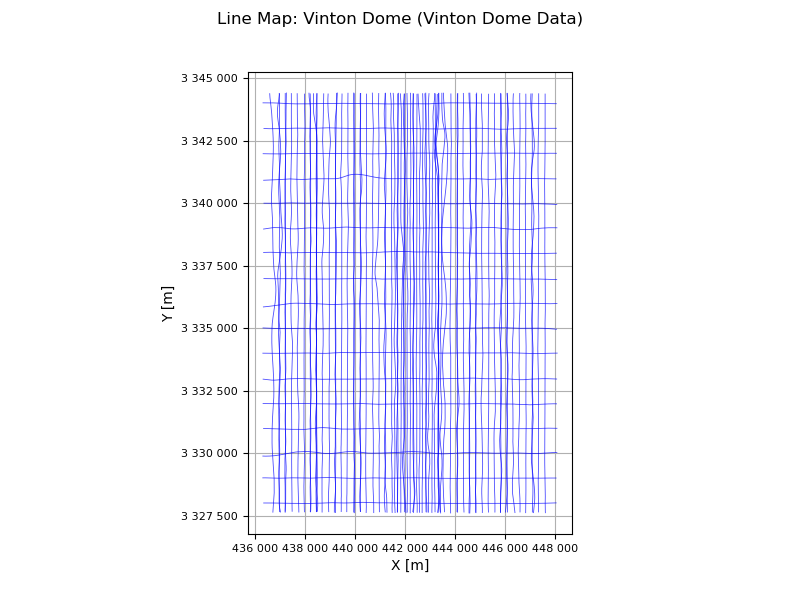

In [7]:
qc.linesMap([vintonHDF_file])

## Navigation and positioning
<div class="alert alert-block alert-info">
NA
<div>

See the Eastern Victoria survey for examples of navigation and positioning QC.

## FTG Gradiometer
<div class="alert alert-block alert-info">
ACCEPT
<div>

> `AirGravQC` includes functions for the QC of FTG data but we do not have field data available to test it on. Instead we will "fake it to make it".

FTG data in the field is delivered with the raw in-line and cross gradients and it is these channels that the following QC functions check. The final data does not include the in-line and cross data and all delivered gradients have been filtered and transformed to components of the tensor representation. The transformation exploits Laplace's equation which means that the ensor trace is, by construction, zero. This makes all the tests against the trace useless.

So these examples would be much more realistic with the raw in-line and cross gradients. Nevertheless, some can be run with the supplied final components and this is done here to demonstrate the use of the functions. The results are, however, meaningless.

> `ilsNoiseVturb()` performs the same task as `diffNoiseVturb()` does for AGG but it uses the in-line sum as the measure of noise instead of the difference noise.

Here we get very low noise estimates because we are inputting (despite the channel names) final transformed data.

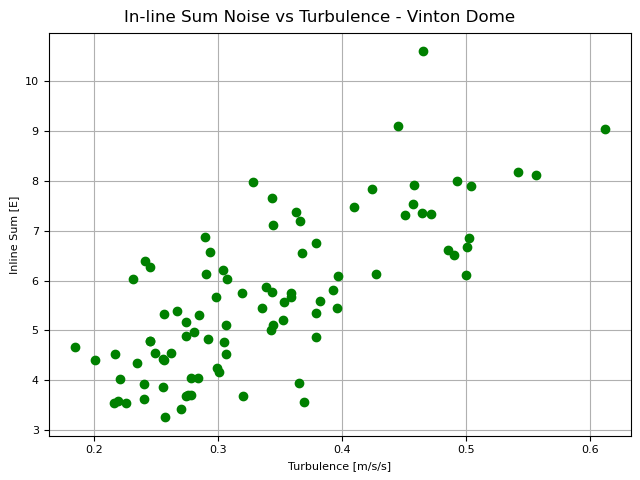

In [11]:
qc.ilsNoiseVturb(vintonHDF_file, 'Inline1_raw', 'Inline2_raw', 'Inline3_raw', vertdispl='altitude')

> `checkHighFreq()` performs the same task as `checkRawAGG()` but using the raw FTG in-line and cross channels.

The aim is to check for periods of excess high frequency noise. The usual `noiseLimit` is 50 but the final data used as input to the function have been heavily filtered and so it has been set to 14 here just to get some plots.

Checked 91 lines; 2 lines had high frequency signal above 14.


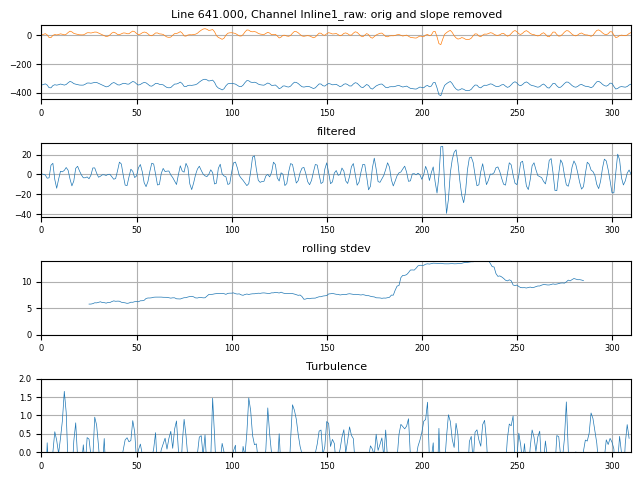

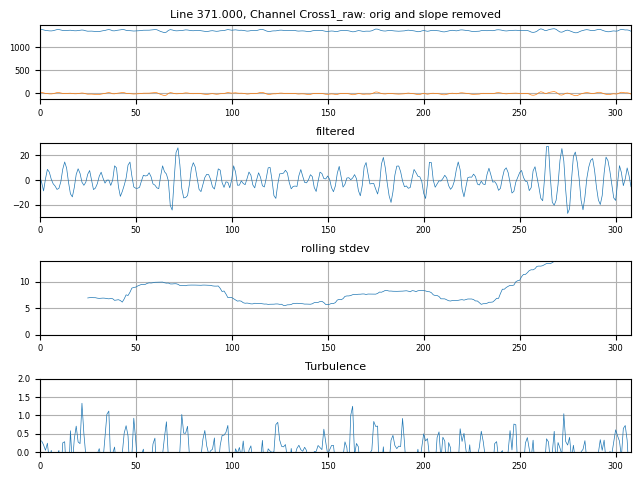

In [12]:
qc.checkHighFreq(vintonHDF_file, noiseLimit=14,
                 channels=['Cross1_raw', 'Cross2_raw', 'Cross3_raw', 'Inline1_raw', 'Inline2_raw', 'Inline3_raw'],
                 cutoffs=[0.1, 0.48], vertdispl='altitude', verbose=False, plot_flag=True)

> `checkInlineSum()` calculates the in-line sum from the raw FTG in-line channels, plotting and reporting results.

By construction, the in-line sum should be zero. We would like the standard deviations less than 20 E, and no major outliers.

These data look as expected.

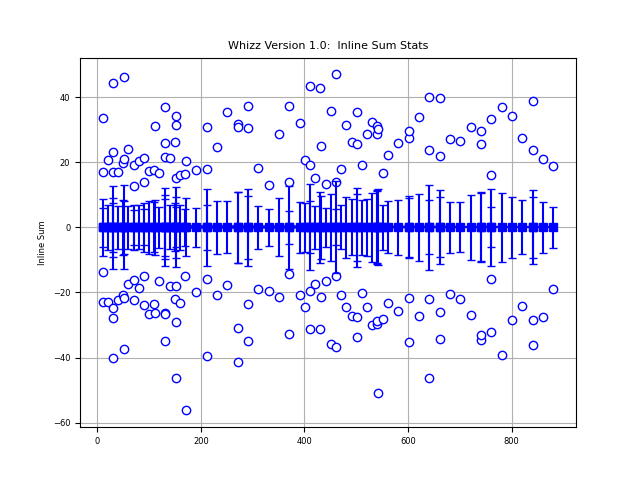

In [13]:
qc.checkInlineSum(vintonHDF_file, inline1='Inline1_raw', inline2='Inline2_raw', inline3='Inline3_raw', dontfilter=True)

> `checkFrobenius()` checks the Frobenius norm of the tensor and plots results if it exceeds the noise limit. This function is still in testing and its results may not yet be useful. It needs a `plot_flag` input.

In [14]:
qc.checkFrobenius(vintonHDF_file, lines = ['10.000', '100.000', '11.000', '110.000', '111.000'], 
                  il1='Inline1_raw', il2='Inline2_raw', il3='Inline3_raw', 
                  cr1='Cross1_raw', cr2='Cross2_raw', cr3='Cross3_raw', noiselimit=30.0)

Check line 10.000. Noise = 117.8
Check line 100.000. Noise = 115.8
Check line 11.000. Noise = 119.0
Check line 110.000. Noise = 117.1
Check line 111.000. Noise = 122.3


## Statistics and Grids
<div class="alert alert-block alert-info">
NA
<div>

### Data Quality
<div class="alert alert-block alert-success">
PASS
<div>

*None of the following checks are contractually required but they can give some insights to data quality.*

> Just plot the mean, standard deviation and range of every channel as a for every line. A lot of information condensed here which I find useful. I just run my eye quickly over the plots looking for outliers, and I check the vertical scales to ensure that the values are in about the right range.
>

Normally, plot the stats for all channels whatsoever. But to save space, we will just do a few in the next notebook cell.

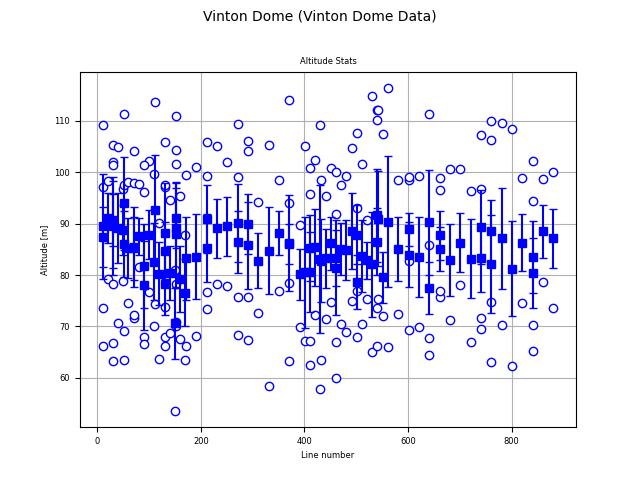

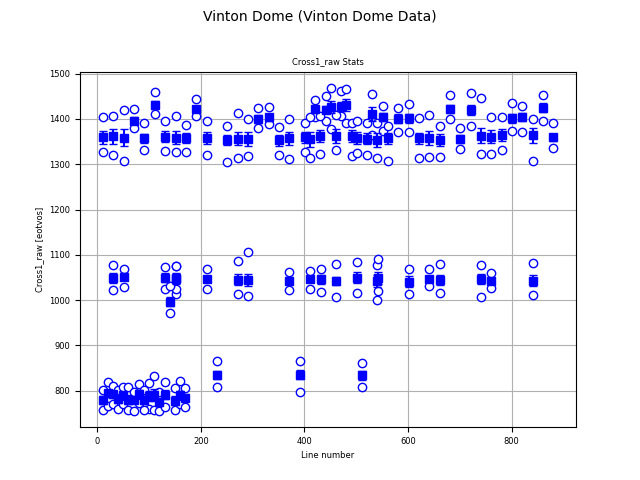

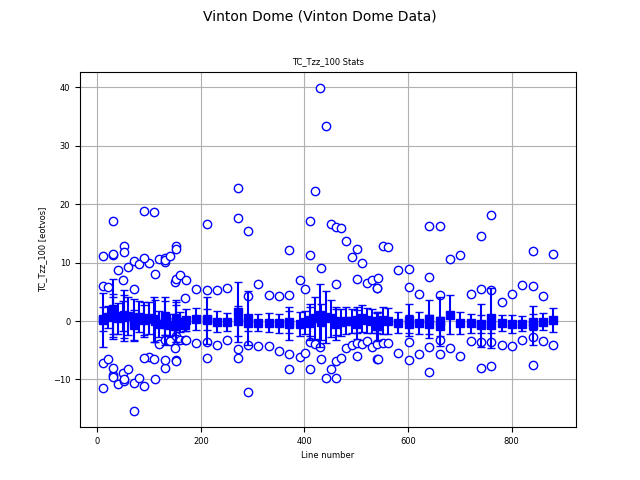

In [23]:
qc.allChanStats(vintonHDF_file, ['Altitude', 'Cross1_raw', 'TC_Tzz_100'])

### Even-Odd Grids
<div class="alert alert-block alert-success">
PASS
<div>

> For the Vinton Dome data, we don't have any specification. This example just demonstrates the use of the function. Note that the user needs to specify the odd and even lines. Often the line numbering system makes this reasonably easy, but not always (and certainly not here).

In [4]:
all = ['10.000', '100.000', '11.000', '110.000', '111.000', '120.000', '130.000', '131.000', 
                  '131.100', '140.000', '150.000', '151.000', '151.100', '151.200', '160.000', '170.000', 
                  '171.000', '191.000', '20.000', '211.000', '211.100', '231.000', '251.000', '271.000', 
                  '271.100', '291.000', '291.100', '30.000', '31.000', '31.100', '311.000', '331.000', 
                  '351.000', '371.000', '371.100', '391.000', '40.000', '401.000', '411.000', '411.100', 
                  '421.000', '431.000', '431.100', '441.000', '451.000', '461.000', '461.100', '471.000', 
                  '481.000', '491.000', '50.000', '501.000', '501.100', '51.000', '51.100', '511.000', 
                  '521.000', '531.000', '541.000', '541.100', '541.200', '551.000', '561.000', '581.000', 
                  '60.000', '601.000', '601.100', '621.000', '641.000', '641.100', '661.000', '661.100', 
                  '681.000', '70.000', '701.000', '71.000', '721.000', '741.000', '741.100', '761.000', 
                  '761.100', '781.000', '80.000', '801.000', '821.000', '841.000', '841.100', '861.000', 
                  '881.000', '90.000', '91.000']
ties = ['10.000', '20.000', '30.000', '40.000', '50.000', 
                  '60.000', '70.000', '80.000', '90.000']
travs = ['11.000', '31.000', '31.100', '71.000', '91.000',  
        '111.000', '131.000', 
                  '131.100', '151.000', '151.100', '151.200',
                  '171.000', '191.000', '211.000', '211.100', '231.000', '251.000', '271.000', 
                  '271.100', '291.000', '291.100', '311.000', '331.000', 
                  '351.000', '371.000', '371.100', '391.000', '401.000', '411.000', '411.100', 
                  '421.000', '431.000', '431.100', '441.000', '451.000', '461.000', '461.100', '471.000', 
                  '481.000', '491.000', '501.000', '501.100', '51.000', '51.100', '511.000', 
                  '521.000', '531.000', '541.000', '541.100', '541.200', '551.000', '561.000', '581.000', 
                  '601.000', '601.100', '621.000', '641.000', '641.100', '661.000', '661.100', 
                  '681.000', '701.000', '71.000', '721.000', '741.000', '741.100', '761.000', 
                  '761.100', '781.000', '801.000', '821.000', '841.000', '841.100', '861.000', 
                  '881.000']
odds = travs[0::2]
evens = travs[1::2]

37 lines; total number of fids in whizz file = 11975.
    Tzz_slv: min = -86.08, max = 79.91.
38 lines; total number of fids in whizz file = 12269.
    Tzz_slv: min = -79.45, max = 78.83.
Processing (x, y, z) = (X, Y, Tzz_slv). Tzz_slv in eotvos.
Processing (x, y, z) = (X, Y, Tzz_slv). Tzz_slv in eotvos.


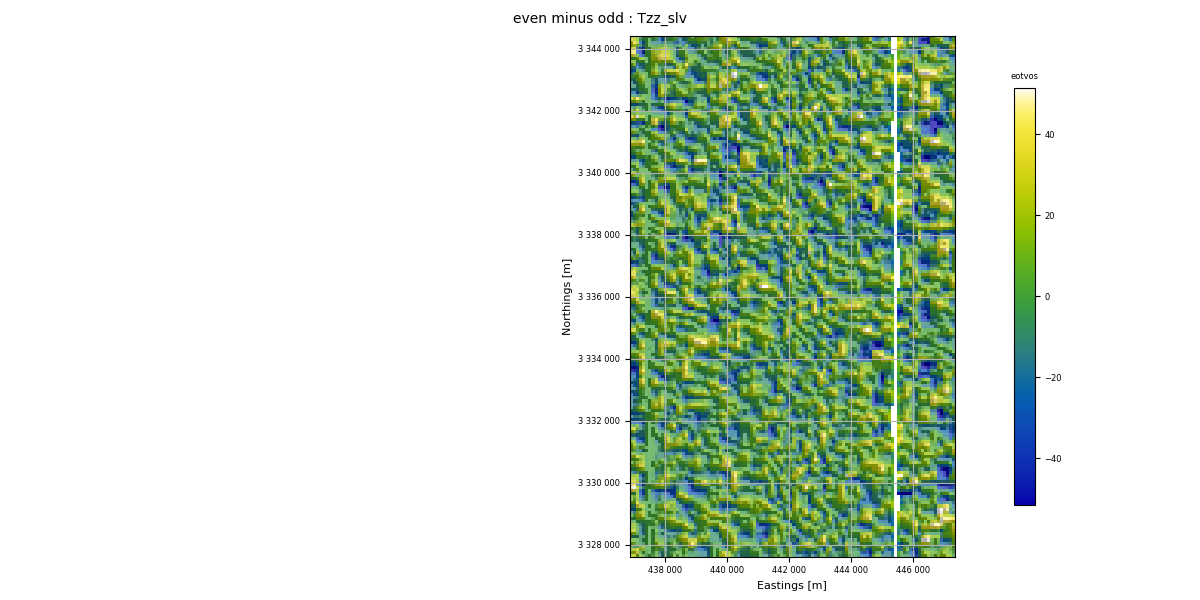

RMS of result = 17.14 eotvos


In [5]:
qc.oddevenlines(vintonHDF_file, 'Tzz_slv', 100.0, oddlines=odds, evenlines=evens, method='neighbours', mask_pixels=3, numneighbours=3)

### Delivered Grids
<div class="alert alert-block alert-info">
NA
<div>

*We don't have delivered grids for Vinton Dome. Look at the Canobie survey QC for examples of QC of delivered grids.*

### Generated Grids
<div class="alert alert-block alert-success">
PASS
<div>

*There are no Deed specifications on the grids except "best practice".*

All the grids look okay and there are no serious artefacts.

> I grid and image almost every channel in the database (here I have only done a few as examples). Channels that are directionally dependent have the mean for each line removed ("mr") before gridding. For some channels it is more useful to examine the grid of the first difference along each line ("d1").

> It might be useful to comment on some particular images.

>> The "long-form parameter" warnings are generated by pygmt version 0.11.0. The older versions of pygmt fail if the long-form parameters are used, so for now, we are living with the warnings.


Gridding and imaging Altitude
91 lines; total number of fids in whizz file = 27865.
    Altitude: min = 53.555, max = 116.345.
Processing (x, y, z) = (X, Y, Altitude). Altitude in m.


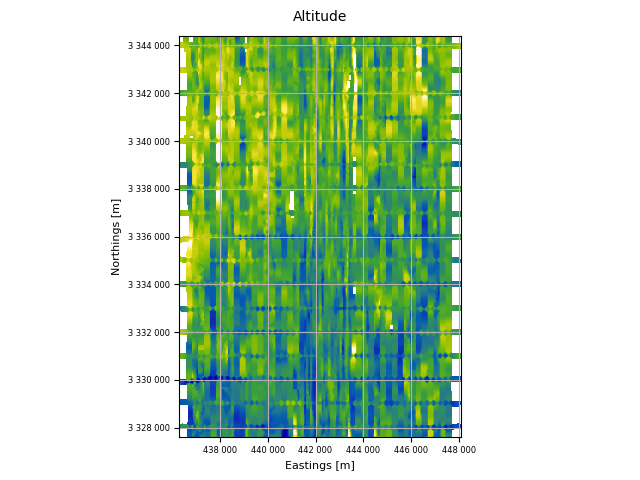

RMS of result = 7.57 m
Gridding and imaging Cross3_raw
91 lines; total number of fids in whizz file = 27865.


In [ ]:
z_chans = ['Altitude', 'Cross3_raw', 'Tzz_slv']
mr_chans = ['Cross3_raw']
d1_chans = ['HHMMSS']

qc.grid_n_image(vintonHDF_file, z_chans, 50.0, mr_chans=mr_chans, d1_chans=d1_chans, method='neighbours', mask_pixels=3, numneighbours=3)

**THE END**